# **INTRODUCTION**

Heart disease is one of the leading causes of death worldwide. Early detection and prediction of heart disease can significantly improve patient outcomes and reduce mortality rates.

This project focuses on building a machine learning model to predict the presence of heart disease based on clinical and medical attributes.

## **PROBLEM STATEMENT**
### The objective of this project is to:
*   Perform exploratory data analysis (EDA)
*   Build multiple classification models
*   Compare model performance
*   Select the best model
*   Provide healthcare insights for early detection
#### Target Variable:
*   heart_disease_present
    *   0 → No disease
    *   1 → Disease present

# 1. IMPORTS

In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Boosting
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
# Tuning
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

# 2. LOAD & MERGE DATA

In [ ]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

OR

In [ ]:
# Download dataset
!wget https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1016-HeartDieseasePred.zip

--2026-04-06 13:16:48--  https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1016-HeartDieseasePred.zip
Resolving d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)... 13.33.47.213, 13.33.47.53, 13.33.47.117, ...
Connecting to d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)|13.33.47.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278938 (272K) [application/x-zip-compressed]
Saving to: ‘PRCP-1016-HeartDieseasePred.zip’

PRCP-1016-HeartDies 100%[===================>] 272.40K  --.-KB/s    in 0.004s  

2026-04-06 13:16:48 (59.5 MB/s) - ‘PRCP-1016-HeartDieseasePred.zip’ saved [278938/278938]



In [ ]:
# unzip dataset
!unzip /content/PRCP-1016-HeartDieseasePred.zip

Archive:  /content/PRCP-1016-HeartDieseasePred.zip
  inflating: Data/values.csv         
  inflating: Data/description.docx   
  inflating: Data/labels.csv         


In [ ]:
values = pd.read_csv("/content/Data/values.csv")
labels = pd.read_csv("/content/Data/labels.csv")


In [ ]:
# Merge
data = pd.merge(values, labels, on="patient_id")

In [ ]:
data.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [ ]:
print("Shape:", data.shape)

Shape: (180, 15)


In [ ]:
# Drop ID
data.drop("patient_id", axis=1, inplace=True) # It’s just a unique identifier(patient_id), not a medical feature.

In [ ]:
print("Shape:", data.shape)
data.head()

Shape: (180, 14)


,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


# 3. DATA UNDERSTANDING

In [ ]:
# Info
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   thal                                  180 non-null    object 
 2   resting_blood_pressure                180 non-null    int64  
 3   chest_pain_type                       180 non-null    int64  
 4   num_major_vessels                     180 non-null    int64  
 5   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 6   resting_ekg_results                   180 non-null    int64  
 7   serum_cholesterol_mg_per_dl           180 non-null    int64  
 8   oldpeak_eq_st_depression              180 non-null    float64
 9   sex                                   180 non-null    int64  
 10  age                                   180 non-null    int64  
 11  max_heart_rate_achi

In [ ]:
# Stats
data.describe()


,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [ ]:
# Missing values
print("\nMissing Values:\n", data.isnull().sum())

# Double-check result:
# No missing values (as dataset says)
# Balanced or slightly imbalanced target


Missing Values:
 slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64


# 4. EDA

## 4.1 Numerical Distribution

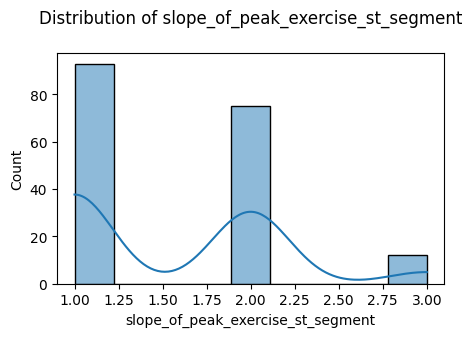

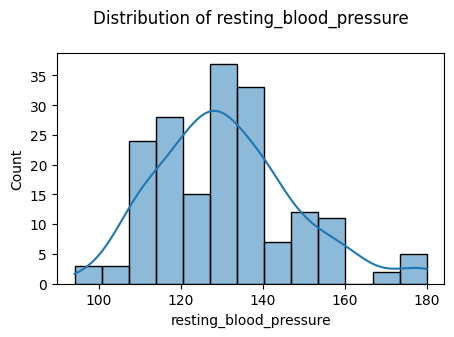

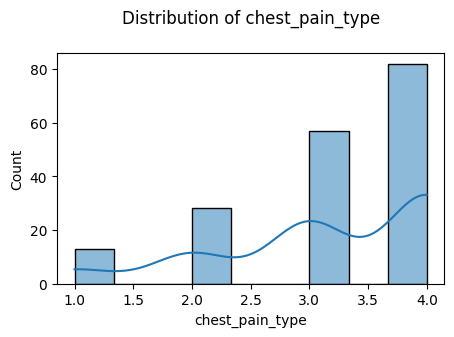

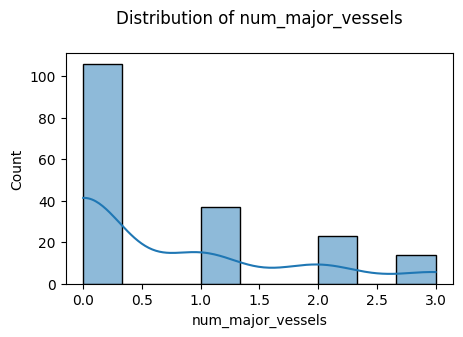

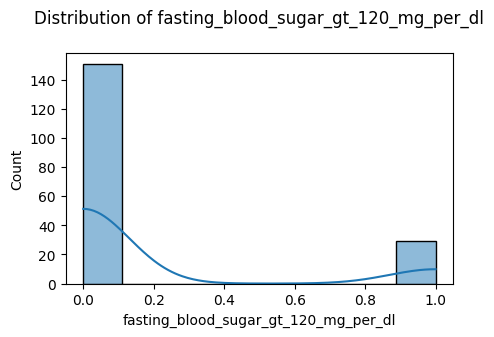

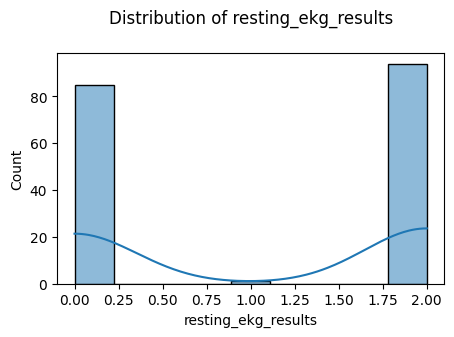

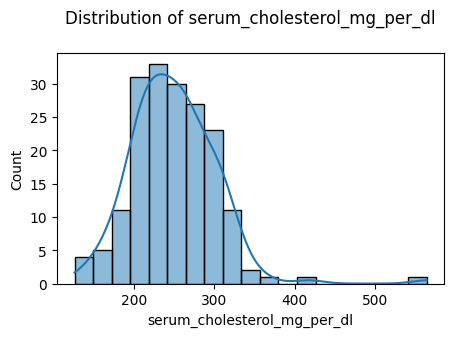

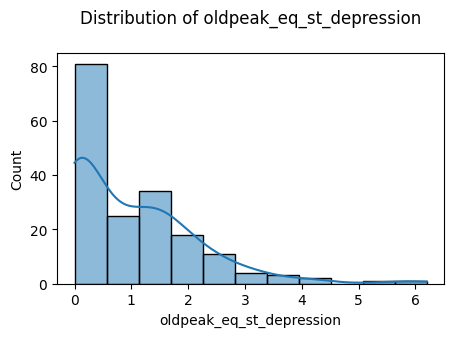

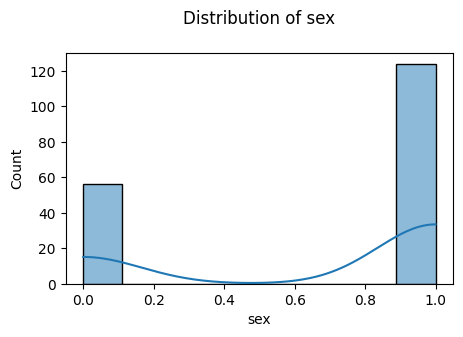

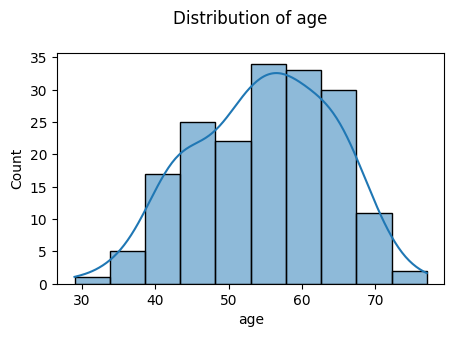

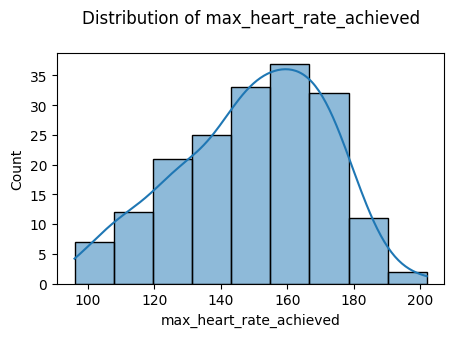

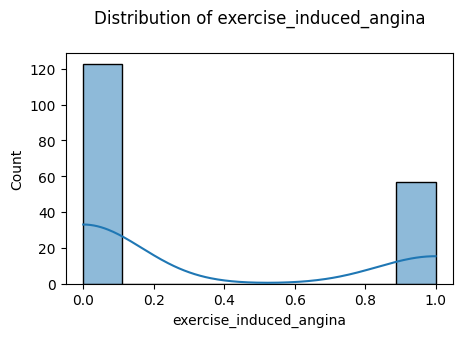

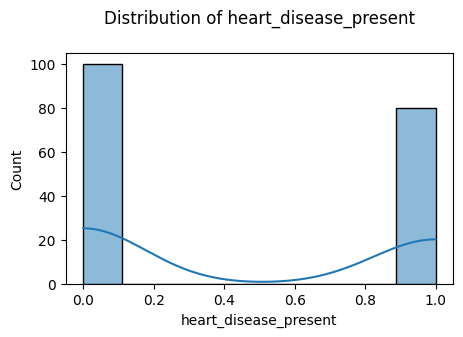

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}\n")
    plt.show()

## 4.2 Correlation Heatmapa

In [ ]:
from sklearn.preprocessing import LabelEncoder


data["thal"] = LabelEncoder().fit_transform(data["thal"])

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

<Axes: >

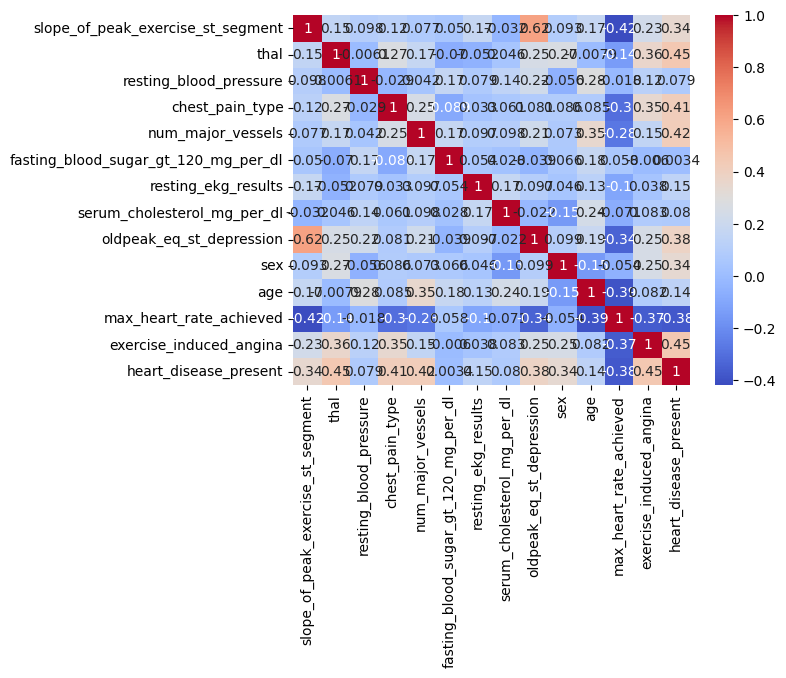

In [ ]:
# Keep original data safe
data_eda = data.copy()

# Only numeric for correlation
corr = data_eda.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

## 4.3 Feature vs Target

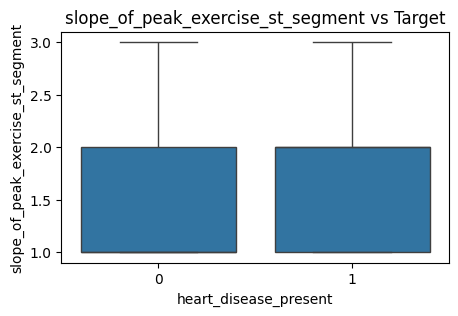

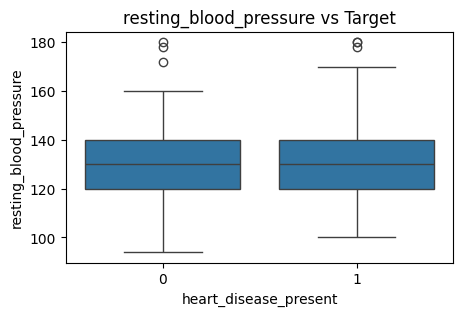

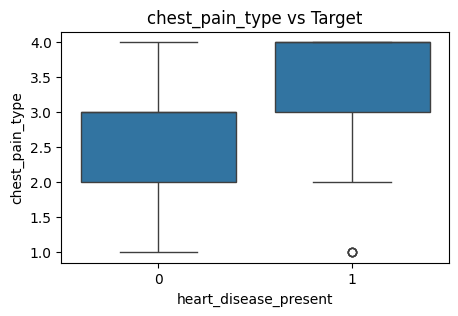

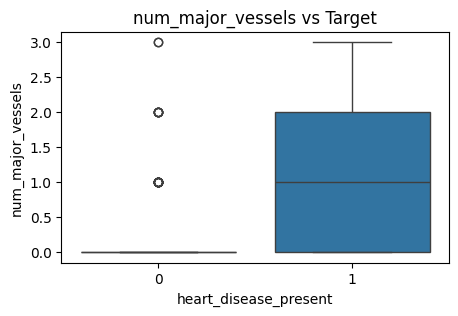

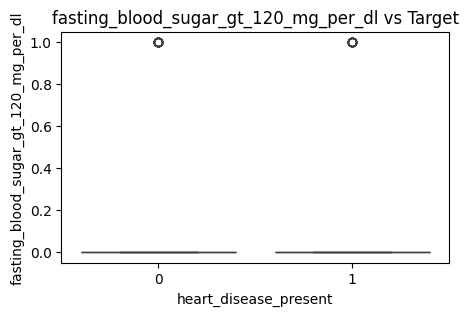

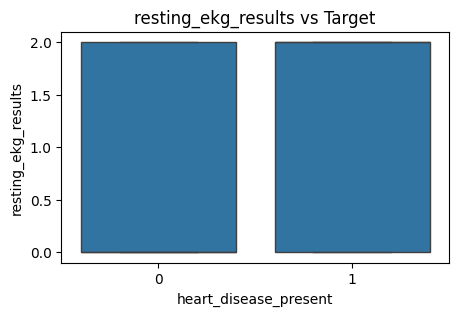

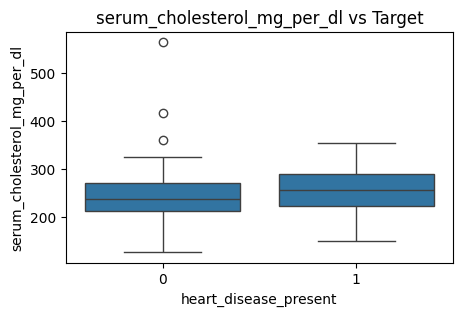

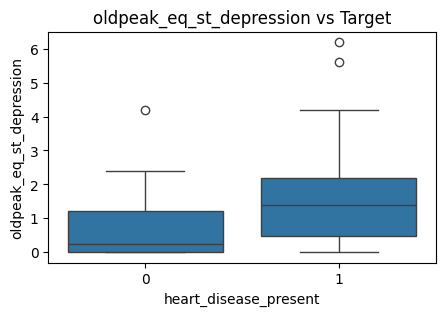

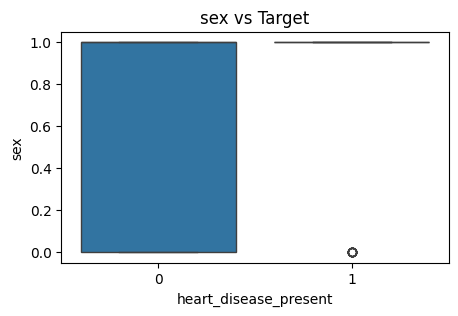

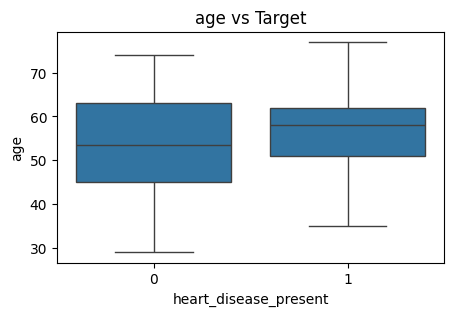

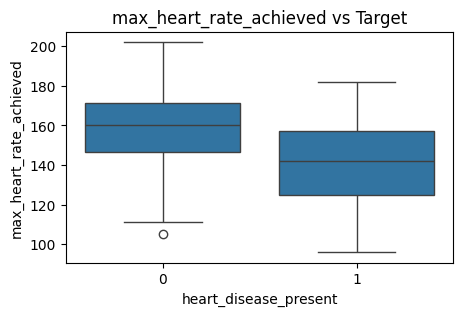

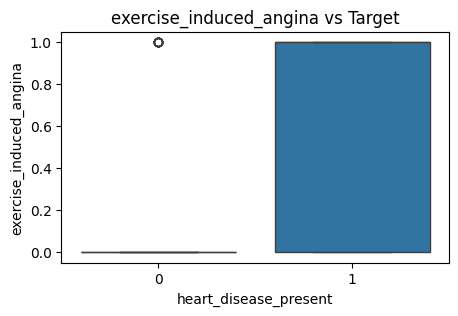

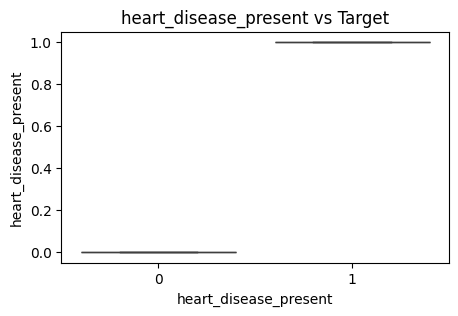

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="heart_disease_present", y=col, data=data)
    plt.title(f"{col} vs Target")
    plt.show()

# 5. FEATURE ENGINEERING

## 5.1 Encode Categorical

In [ ]:
# thal is categorical
data["thal"] = LabelEncoder().fit_transform(data["thal"])

## 5.2 Split Features & Targeta

In [ ]:
X = data.drop("heart_disease_present", axis=1)
y = data["heart_disease_present"]

## 5.3 Train-Test Splita

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=53, stratify=y
)

## 5.4 Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **6. MODEL BUILDING**

## Model Dictionary

In [ ]:
# Scaled data (for some models)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
"""models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}"""

'models = {\n    "Logistic Regression": LogisticRegression(),\n    "Decision Tree": DecisionTreeClassifier(),\n    "Random Forest": RandomForestClassifier(),\n    "Gradient Boosting": GradientBoostingClassifier(),\n    "SVM": SVC(probability=True),\n    "KNN": KNeighborsClassifier(),\n    "Naive Bayes": GaussianNB(),\n    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric=\'logloss\')\n}'

## 1. LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8703703703703703


## 2. DECISION Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6851851851851852


## 3. RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8333333333333334


## 4. GRADIENT BOOSTING

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7777777777777778


## 5. XGBOOST

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.7962962962962963


## 6. SUPPORT VECTOR MACHINE (SVM)

In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8333333333333334


## 7. K-NEAREST NEIGHBORS (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.8333333333333334


## 8. NAIVE BAYESa

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8333333333333334


## 7. MODEL EVALUATION FUNCTIONa

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix

def print_metrics(name, y_test, y_pred, y_prob=None):
    print(f"\n{name}")
    print("="*40)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    if y_prob is not None:
        print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print_metrics("Logistic Regression", y_test, lr_pred, lr_prob)


Logistic Regression
Accuracy : 0.8703703703703703
Precision: 0.9473684210526315
Recall   : 0.75
F1 Score : 0.8372093023255814
ROC-AUC  : 0.8652777777777778

Confusion Matrix:
[[29  1]
 [ 6 18]]


In [ ]:
print_metrics("Random Forest", y_test, rf_pred, rf.predict_proba(X_test)[:,1])



Random Forest
Accuracy : 0.8333333333333334
Precision: 0.8571428571428571
Recall   : 0.75
F1 Score : 0.8
ROC-AUC  : 0.8875000000000001

Confusion Matrix:
[[27  3]
 [ 6 18]]


In [ ]:
print_metrics("SVM", y_test, svm_pred, svm.predict_proba(X_test_scaled)[:,1])


SVM
Accuracy : 0.8333333333333334
Precision: 0.8947368421052632
Recall   : 0.7083333333333334
F1 Score : 0.7906976744186046
ROC-AUC  : 0.8673611111111112

Confusion Matrix:
[[28  2]
 [ 7 17]]


# 8. TRAIN ALL MODELS

### Step 1: Collect Results Properly

In [ ]:
# Store results
results = []

def evaluate_and_store(name, model, X_train, X_test, y_train, y_test, scaled=False):

    if scaled:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

### Step 2: Run All Modelsa

In [ ]:
evaluate_and_store("Logistic Regression", LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)

evaluate_and_store("Decision Tree", DecisionTreeClassifier(), X_train, X_test, y_train, y_test)

evaluate_and_store("Random Forest", RandomForestClassifier(), X_train, X_test, y_train, y_test)

evaluate_and_store("Gradient Boosting", GradientBoostingClassifier(), X_train, X_test, y_train, y_test)

evaluate_and_store("SVM", SVC(probability=True), X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)

evaluate_and_store("KNN", KNeighborsClassifier(), X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)

evaluate_and_store("Naive Bayes", GaussianNB(), X_train, X_test, y_train, y_test)

evaluate_and_store("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), X_train, X_test, y_train, y_test)

### Step 3: Create Comparison Table

In [ ]:
results_df = pd.DataFrame(results)

# Sort by ROC-AUC (best metric for healthcare)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# Reset index for clean display
results_df.reset_index(drop=True, inplace=True)

print("\n📊 Model Comparison Table:")
display(results_df)


📊 Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Naive Bayes,0.833333,0.857143,0.750000,0.800000,0.911111
1,Random Forest,0.833333,0.894737,0.708333,0.790698,0.886806
2,SVM,0.833333,0.894737,0.708333,0.790698,0.866667
3,Logistic Regression,0.870370,0.947368,0.750000,0.837209,0.865278
4,KNN,0.833333,0.857143,0.750000,0.800000,0.861111
5,XGBoost,0.796296,0.882353,0.625000,0.731707,0.829167
6,Gradient Boosting,0.759259,0.823529,0.583333,0.682927,0.819444
7,Decision Tree,0.666667,0.687500,0.458333,0.550000,0.645833


### Highlight Best Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

print(f"\n🏆 Best Model Based on ROC-AUC: {best_model_name}")


🏆 Best Model Based on ROC-AUC: Naive Bayes


# 9. BEST MODEL SELECTION
How to Choose (Healthcare Rule), Priority Order:

1. Recall (MOST IMPORTANT) → don’t miss patients
2. ROC-AUC → overall performance
3. F1 Score → balance
4. Accuracy → least important

Among all models, Naive Bayes achieved the highest ROC-AUC score (0.91), indicating superior ability to distinguish between patients with and without heart disease. Although Logistic Regression showed slightly higher accuracy, Naive Bayes maintained a strong balance between recall and overall performance. Since minimizing false negatives is critical in healthcare applications, Naive Bayes was selected as the final model.

Why Naive Bayes?
1. Highest ROC-AUC (0.911) → best separation ability
2. Good Recall (0.75) → detects most patients
3. Balanced performance across metrics
4. Works well on small datasets
5. Less overfitting compared to tree models

## 1. Cross Validation

In [ ]:
cross_val_score(nb, X, y, cv=5, scoring='roc_auc').mean()

np.float64(0.884375)

## 2. Check Overfitting

In [ ]:
print(nb.score(X_train, y_train))
print(nb.score(X_test, y_test))

0.8650793650793651
0.8333333333333334


## 3. Feature Importance (Logistic)

<Axes: >

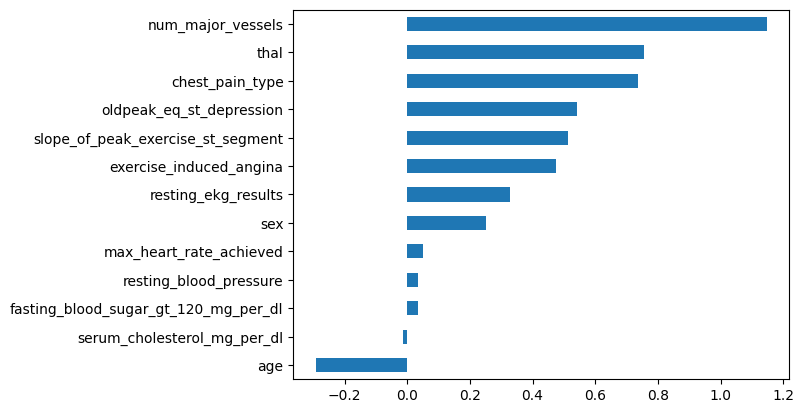

In [ ]:
coef = pd.Series(lr.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh')

### Final Model Selection

In [ ]:

from sklearn.naive_bayes import GaussianNB

final_model = GaussianNB()

final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:,1]

# Final Metrics
print_metrics("Final Model (Naive Bayes)", y_test, y_pred_final, y_prob_final)


Final Model (Naive Bayes)
Accuracy : 0.8333333333333334
Precision: 0.8571428571428571
Recall   : 0.75
F1 Score : 0.8
ROC-AUC  : 0.9111111111111112

Confusion Matrix:
[[27  3]
 [ 6 18]]


## Save Final Model

In [ ]:
import pickle

pickle.dump(final_model, open("final_heart_model.pkl", "wb"))

# 10. HYPERPARAMETER TUNING

**Important:** Not all models benefit equally

## 10.1 Logistic Regression

In [ ]:
lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring="roc_auc"
)

lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_

print("Best LR Params:", lr_grid.best_params_)

Best LR Params: {'C': 0.01, 'solver': 'lbfgs'}


## 10.2 Decision Tree

In [ ]:
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    cv=5,
    scoring="roc_auc"
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("Best DT Params:", dt_grid.best_params_)

Best DT Params: {'max_depth': 3, 'min_samples_split': 10}


## 10.3 Random Forest

In [ ]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


## 10.4 Gradient Boosting

In [ ]:
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    scoring="roc_auc"
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("Best GB Params:", gb_grid.best_params_)

Best GB Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


## 10.5 SVM

In [ ]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    scoring="roc_auc"
)

svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_

print("Best SVM Params:", svm_grid.best_params_)

Best SVM Params: {'C': 0.1, 'kernel': 'rbf'}


## 10.6 KNN

In [ ]:
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="roc_auc"
)

knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_

print("Best KNN Params:", knn_grid.best_params_)

Best KNN Params: {'n_neighbors': 9, 'weights': 'distance'}


## 10.7 XGBoost

In [ ]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print("Best XGB Params:", xgb_grid.best_params_)

Best XGB Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


## 10.8 Naive Bayes

In [ ]:
nb_params = {
    "var_smoothing": [1e-9, 1e-8, 1e-7]
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    cv=5,
    scoring="roc_auc"
)

nb_grid.fit(X_train, y_train)

best_nb = nb_grid.best_estimator_

print("Best NB Params:", nb_grid.best_params_)

Best NB Params: {'var_smoothing': 1e-09}


# 11. FINAL CHECK AFTER TUNING

In [ ]:
print_metrics("Tuned Naive Bayes", y_test,
              best_nb.predict(X_test),
              best_nb.predict_proba(X_test)[:,1])


Tuned Naive Bayes
Accuracy : 0.8333333333333334
Precision: 0.8571428571428571
Recall   : 0.75
F1 Score : 0.8
ROC-AUC  : 0.9111111111111112

Confusion Matrix:
[[27  3]
 [ 6 18]]


# 12. FINAL MODEL SELECTION

Selected Model: Naive Bayes Reasoning:
*   Highest ROC-AUC (0.91)
*   Good Recall (0.75)
*   Balanced performance
*   Low complexity and stable

Key Insight:-
In healthcare, recall is critical to avoid missing patients. Naive Bayes provides strong detection ability while maintaining high overall performance.

# 13. CHALLENGES & SOLUTIONS

| Challenge                 | Solution                 |
| ------------------------- | ------------------------ |
| Mixed data types          | Applied encoding         |
| Scaling requirements      | Used StandardScaler      |
| Model selection confusion | Compared multiple models |
| Overfitting risk          | Used cross-validation    |

# 14. HEALTHCARE INSIGHTS
*   Patients with high chest pain levels are at greater risk
*   Exercise-induced angina is a strong indicator
*   High cholesterol + BP increases probability
*   Early detection can significantly reduce mortality

# 15. CONCLUSION

Machine learning models were successfully developed to predict heart disease.
*   Multiple models were compared
*   Naive Bayes achieved best ROC-AUC
*   Model can assist doctors in early diagnosis
